<a href="https://colab.research.google.com/github/Zaka123456/MRP/blob/main/03_XGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# === Install Dependencies ===
!pip install -q xgboost scikit-learn

# === Imports ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from scipy.stats import uniform, randint

# === Load and Prepare Data ===
file_path = "/content/drive/MyDrive/MRP/Current/Deliverables/Methodology_&_Experiments/Report/Coding/Data_files/Final_Selected_Features_new.csv"
df = pd.read_csv(file_path, parse_dates=["date_only"])
df = df.sort_values("date_only")



In [3]:
# === Fill Missing Values ===
weather_cols = ['tempmax', 'humidity', 'solarradiation']
lag_cols = ['Sales_lag_1', 'temp_lag_1', 'temp_lag_7', 'temp_lag_30']

for col in weather_cols + lag_cols:
    df[col] = df[col].fillna(method='ffill').fillna(method='bfill')

display(df.isnull().sum())

/tmp/ipython-input-1673397667.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='ffill').fillna(method='bfill')


,0
Sales,0
Order Profit Per Order,0
Order Item Quantity,0
Order Item Discount,0
Order Item Discount Rate,0
Order Item Profit Ratio,0
Product Card Id,0
Type_DEBIT,0
Delivery Status_Late delivery,0
Market_LATAM,0


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters:
{'learning_rate': np.float64(0.06318730785749581), 'max_depth': 6, 'n_estimators': 363, 'subsample': np.float64(0.8099025726528951)}

=== Test Set Evaluation ===
MAE   : 38.52
RMSE  : 66.77
sMAPE : 7.89%
R²    : 0.961


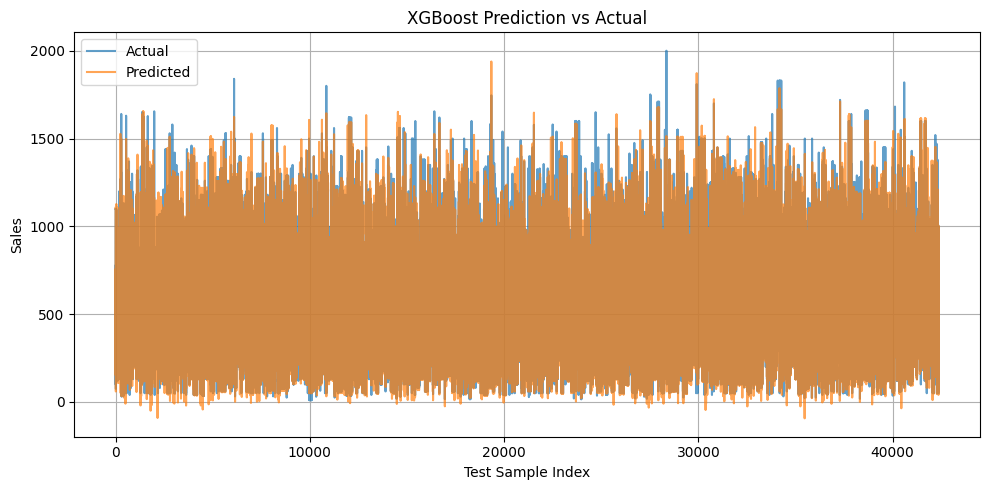

In [4]:
# === Feature/Target Split ===
target = "Sales"
X = df.drop(columns=["Sales", "date_only", "latitude", "longitude"]).select_dtypes(include=[np.number])
y = df[target]

# === Normalize Features ===
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# === Train-Test Split (no shuffle) ===
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

# === Define XGBoost and Parameter Grid ===
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_dist = {
    "n_estimators": randint(50, 601),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.01, 0.29),  # 0.01–0.3
    "subsample": uniform(0.6, 0.4),        # 0.6–1.0
}

# === Randomized Search with 3-Fold CV ===
random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

# === Best Model and Parameters ===
best_model = random_search.best_estimator_
print("\nBest Parameters:")
print(random_search.best_params_)

# === Predict and Evaluate ===
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred)
    return np.mean(np.where(denominator == 0, 0, diff / denominator)) * 100

s_mape = smape(y_test.values, y_pred)
r2 = r2_score(y_test, y_pred)

# === Print Results ===
print("\n=== Test Set Evaluation ===")
print(f"MAE   : {mae:.2f}")
print(f"RMSE  : {rmse:.2f}")
print(f"sMAPE : {s_mape:.2f}%")
print(f"R²    : {r2:.3f}")

# === Plot Results ===
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual", alpha=0.7)
plt.plot(y_pred, label="Predicted", alpha=0.7)
plt.title("XGBoost Prediction vs Actual")
plt.xlabel("Test Sample Index")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MRP/Current/Deliverables/Methodology_&_Experiments/Report/Coding/Data_files/Plots/xgboost_prediction_vs_actual.png")
plt.show()